# Практическое занятие №7: Машинное обучение с scikit-learn I.

## Цели занятия:
1. Обучающая: 

    Сформировать у студентов практические навыки подготовки данных для решения 
задач машинного обучения: выделение признаков (матрица X) и целевой переменной 
(y), разделение набора данных на обучающую и тестовую выборки с помощью 
функции train_test_split(). 

2. Развивающая: 

Научить студентов применять алгоритмы линейной регрессии и k-ближайших 
соседей (k-NN) для решения задач регрессии и классификации, а также осознанно 
выбирать между ними в зависимости от характера данных. 

3. Воспитательная: 

Привить культуру объективной оценки моделей машинного обучения, 
акцентировать внимание на недопустимости использования тестовых данных в 
процессе обучения. 

### Выполнил: Мамаев А.
### Вариант 4: Ирисы Фишера (задача многоклассовой классификации) 

In [2]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Настройка отображения графиков
%matplotlib inline
sns.set_style('whitegrid')

In [4]:
# Загрузка датасета Iris
iris = load_iris()

In [7]:
# Создание DataFrame и признака target (числовое представления вида лепестка для машинного обучения)
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

In [12]:
print(f"\n1. Формат данных: {df.shape}")


1. Формат данных: (150, 6)


In [13]:
print("\n2. Информация о данных:")
df.info()


2. Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [14]:
print("\n3. Первые 5 строк:")
print(df.head())


3. Первые 5 строк:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


In [16]:
print("\n4. Статистика признаков:")
print(df.describe())


4. Статистика признаков:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [17]:
print("\n5. Распределение классов:")
print(df['species'].value_counts())


5. Распределение классов:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


 **Выводы по заданному датасету:** Датасет содержит 150 образцов, 4 признака, 3 класса по 50 образцов. Пропусков нет.

In [20]:
# Выделение признаков и целевой переменной
X = iris.data  # матрица признаков
y = iris.target # целевая переменная

In [21]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(f"\nРазмер обучающей выборки: {X_train.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")


Размер обучающей выборки: 120 образцов
Размер тестовой выборки: 30 образцов


In [39]:
# Создание и обучение модели
# k=5
knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model.fit(X_train, y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
# Предсказание
y_pred = knn_model.predict(X_test)

Теперь произведем оценку качества модели при k=3

In [42]:
# Метрика 1: Accuracy (точность)
accuracy = accuracy_score(y_test, y_pred)
print(f"1. Accuracy (точность): {accuracy:.3f}")

# Метрика 2: Classification Report
print("\n2. Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Дополнительно: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

1. Accuracy (точность): 0.933

2. Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



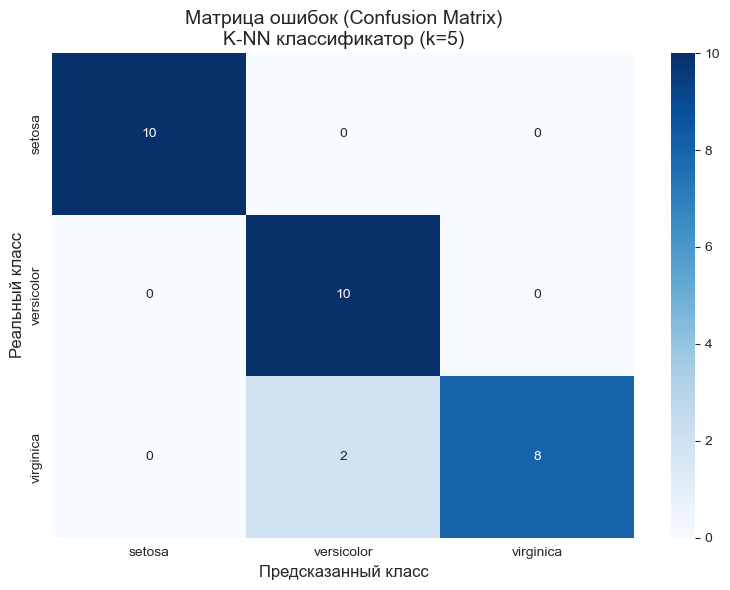

In [43]:
# Тепловая карта матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Матрица ошибок (Confusion Matrix)\nK-NN классификатор (k=5)', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Реальный класс', fontsize=12)
plt.tight_layout()
plt.show()

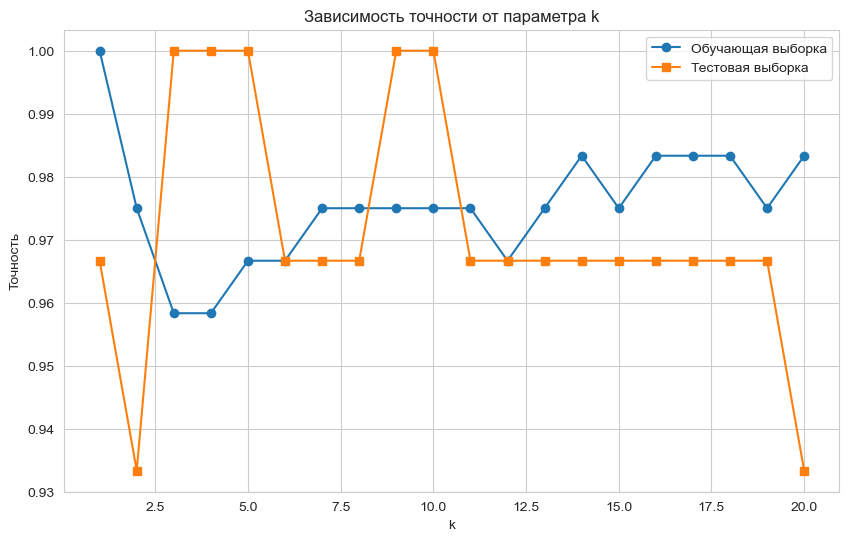

Наилучшее k: 3 с точностью 1.000


In [44]:
# Улучшение: Подбор оптимального k
k_values = range(1, 21) 
train_scores = [] 
test_scores = []

for k in k_values: 
    knn_tmp = KNeighborsClassifier(n_neighbors=k) 
    knn_tmp.fit(X_train, y_train) 
    train_scores.append(knn_tmp.score(X_train, y_train)) 
    test_scores.append(knn_tmp.score(X_test, y_test)) 

plt.figure(figsize=(10, 6)) 
plt.plot(k_values, train_scores, label='Обучающая выборка', marker='o') 
plt.plot(k_values, test_scores, label='Тестовая выборка', marker='s') 
plt.xlabel('k') 
plt.ylabel('Точность') 
plt.legend() 
plt.title('Зависимость точности от параметра k') 
plt.show() 

# Находим оптимальное k 
best_k = k_values[test_scores.index(max(test_scores))] 
print(f"Наилучшее k: {best_k} с точностью {max(test_scores):.3f}") 

In [48]:
# Финальная улучшенная модель
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

y_pred_best = knn_best.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy улучшенной модели: {accuracy_best:.3f}")

Accuracy улучшенной модели: 1.000


**Вывод:** Улучшенная модель с k=3 показала лучший результат по сравнению с базовой моделью (k=2).
- k=2 — слишком мало, может привести к переобучение
- k=3 — оптимально, хорошая обобщающая способность
- Дальнейшее увеличение k (например, k=5) может привести к недообучению